In [1]:
%matplotlib widget

# Perform laterally constrained inversion on Field data Ackerdijkse Plassen

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import sys
sys.path.insert(1, '../src')

from FDEM1D import FDEM1DModelling_field, LCModelling
from showStitched import showStitchedModels
from sklearn.metrics import root_mean_squared_error


/tmp/ipykernel_3792592/488155922.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# 1. Load data

Dataframe = pd.DataFrame(np.load('data/Field_data.npy'),
                        columns = ['X','Y','Position','Z','H2Q','H4Q','H8Q',
                                   'V2Q','V4Q','V8Q','P2Q','P4Q','P8Q',
                                   'H4IP','H8IP','V4IP','V8IP'])

In [4]:
# Obtain H and V quadrature and in-phase measurements
# For in-phase we only use measurements for offsets > 4 m
data = np.array(pd.concat([Dataframe.loc[:,'H2Q':'V8Q'], Dataframe.loc[:,'H4IP':]], axis=1))
npos = len(data) # number of 1D models
nlay = 2 # number of layers

nM=50 # number of measurements per line

nLines = int(npos/50)

In [5]:
# Define an initial model

model_ini = np.ones((nM,3))
model_ini[:,0] = model_ini[:,0]*3   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.1 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.1 # initial sigma_2

# Perform laterally constrained inversion in each line

In [6]:
model_inv_full = []
response_full = []

for nL in range(nLines):

    data_L = data[nL*nM:(nL+1)*nM]
    
    LCI = LCModelling(FDEM1DModelling_field)
    
    LCI.initJacobian(dataVals=data_L, nLay=nlay)
    LCI.createJacobian(model_ini)
    LCI.constraint_matrix(data_L, nLay=nlay)
    LCI.normalization(data_L, cWeight_1=1, cWeight_2=1, nLay=nlay)
    LCI.createWeight(data_L, cWeight_1=1, cWeight_2=1, nLay=nlay)
    LCI.createConstraints()
    
    # Set transforms
    #transData = pg.trans.TransLog()
    transThk = pg.trans.TransLogLU(0.1,5)
    transSig = pg.trans.TransLogLU(1/1000,500/1000)
    
    LCI.region(1).setTransModel(transThk)
    LCI.region(2).setTransModel(transSig)

    # Create data vector
    data_vector = data_L.ravel()
    relativeError = np.ones_like(data_vector)*1e-3 
    
    # Run inversion
    inv = pg.Inversion(LCI)
    #inv.dataTrans = transData
    model_inv = inv.run(data_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1 )
    
    model_inv_full.append(model_inv)
    response_full.append(inv.response)
    

Inversion is normalized
Jacobian size: 490 147 500


14/08/25 - 13:53:36 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/08/25 - 13:53:36 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f76dac090d0>
Inversion is normalized
Jacobian size: 490 147 500


14/08/25 - 13:53:39 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/08/25 - 13:53:39 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f76dac0a7f0>
Inversion is normalized
Jacobian size: 490 147 500


...

cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f76db64a390>
Inversion is normalized
Jacobian size: 490 147 500


14/08/25 - 13:55:06 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/08/25 - 13:55:06 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f7761af04a0>
Inversion is normalized
Jacobian size: 490 147 500


14/08/25 - 13:55:10 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/08/25 - 13:55:10 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f76dac90630>


In [7]:
model_inv = np.array(model_inv_full).reshape(nLines*nM,3)
responses = np.array(response_full).reshape(nLines*nM,10)

In [8]:
air_layer = np.zeros_like(model_inv[:,0])
air_layer_height = -Dataframe['Z']

In [9]:
model_inv_topo = np.stack((air_layer_height, model_inv[:,0], air_layer, model_inv[:,1]*1000, model_inv[:,2]*1000), axis=1)

In [10]:
Model_inv_frame =pd.DataFrame(model_inv, columns= ['h_1', 's_1', 's_2'])

In [11]:
rmse_L1 = root_mean_squared_error(data[0:50], responses[0:50])*1000
rmse_L18 = root_mean_squared_error(data[900:950], responses[900:950])*1000
rmse_L36 = root_mean_squared_error(data[1800:], responses[1800:])*1000


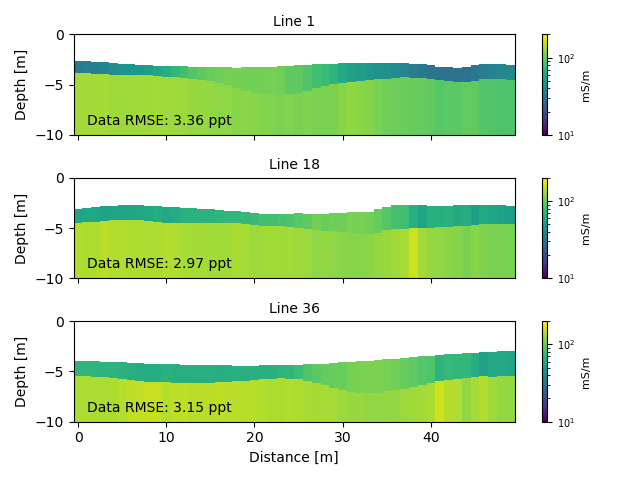

In [12]:
fig, ax = plt.subplots(3,1, sharex=True, )

fs=10
showStitchedModels(model_inv_topo[0:50], ax=ax[0], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[0].set_title('Line 1', fontsize=fs)
ax[0].set_ylabel('Depth [m]', fontsize=fs)
ax[0].text(1, -9, 'Data RMSE: ' + format(rmse_L1, ".2f") + ' ppt')

showStitchedModels(model_inv_topo[900:950], ax=ax[1], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[1].set_title('Line 18', fontsize=fs)
ax[1].set_ylabel('Depth [m]', fontsize=fs)
ax[1].text(1, -9, 'Data RMSE: ' + format(rmse_L18, ".2f") + ' ppt')

showStitchedModels(model_inv_topo[1800:], ax=ax[2], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[2].set_title('Line 36', fontsize=fs)
ax[2].set_ylabel('Depth [m]', fontsize=fs)
ax[2].set_xlabel('Distance [m]', fontsize=fs)
ax[2].text(1, -9, 'Data RMSE: ' + format(rmse_L36, ".2f") + ' ppt')

#fig.suptitle('LCI estimated models')
plt.tight_layout()
plt.savefig('figures/Lines_LCI.eps', format='eps')
plt.show()

In [13]:
X = Dataframe['X']
Y = Dataframe['Y']
h_1 = Model_inv_frame['h_1']
s_1 = Model_inv_frame['s_1']*1000
s_2 = Model_inv_frame['s_2']*1000

In [14]:
plt.style.use('bmh')

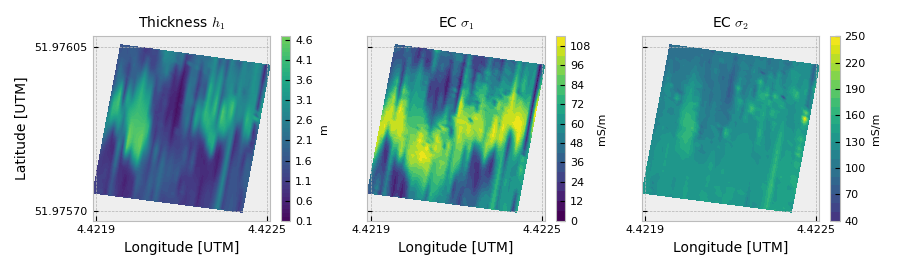

In [15]:
fig, ax = plt.subplots(1,3, figsize=(9,2.7), sharey=True)

cb0 = ax[0].tricontourf(X, Y, h_1, vmin=0, vmax=6, levels=50, cmap='viridis',)
ax[0].set_title('Thickness $h_1$', fontsize=fs)
ax[0].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[0].set_ylabel('Latitude [UTM]', fontsize=fs)
ax[0].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[0].ticklabel_format(useOffset=False)
ax[0].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[0].tick_params(labelsize=8)


cb1 = ax[1].tricontourf(X, Y, np.array(s_1),  levels=20, cmap='viridis', vmin=5)
ax[1].set_title('EC $\sigma_1$', fontsize=fs)
ax[1].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[1].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[1].ticklabel_format(useOffset=False)
ax[1].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[1].tick_params(labelsize=8)

cb2 = ax[2].tricontourf(X, Y, np.array(s_2),  levels=20, cmap='viridis', vmin=5)
ax[2].set_title('EC $\sigma_2$', fontsize=fs)
ax[2].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[2].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[2].ticklabel_format(useOffset=False)
ax[2].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[2].tick_params(labelsize=8)

c1 = fig.colorbar(cb0, ax=ax[0],)
c1.set_label('m', fontsize=8)
c1.ax.tick_params(labelsize=8)

c2 = fig.colorbar(cb1, ax=ax[1],  boundaries=(5, 300))
c2.set_label('mS/m', fontsize=8)
c2.ax.tick_params(labelsize=8)

c3 = fig.colorbar(cb2, ax=ax[2], boundaries=(5, 300))
c3.set_label('mS/m', fontsize=8)
c3.ax.tick_params(labelsize=8)

#fig.suptitle('LCI estimated models')

plt.tight_layout()
plt.savefig('Maps_LCI.eps', format='eps')
plt.show()

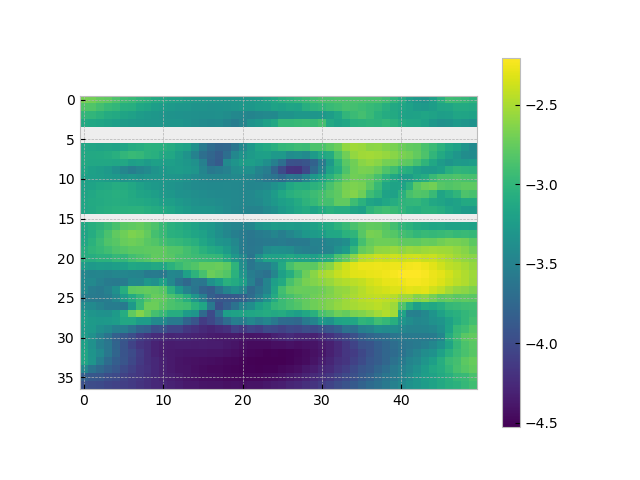

In [16]:
fig, ax = plt.subplots()

c = ax.imshow(np.array(Dataframe['Z']).reshape(37,50), )
fig.colorbar(c)

# Compare data

In [17]:
data_inv = np.array(response_full)
data_inv = data_inv.reshape((37,50,10))

In [18]:
np.save('data/data_inv_LCI', data_inv)

In [19]:
data_inv_pw = np.load('data/data_inv_PWI.npy')

In [20]:
data_true = data.reshape((37,50,10))

14/08/25 - 14:10:56 - matplotlib.backends.backend_ps - WARNING - The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


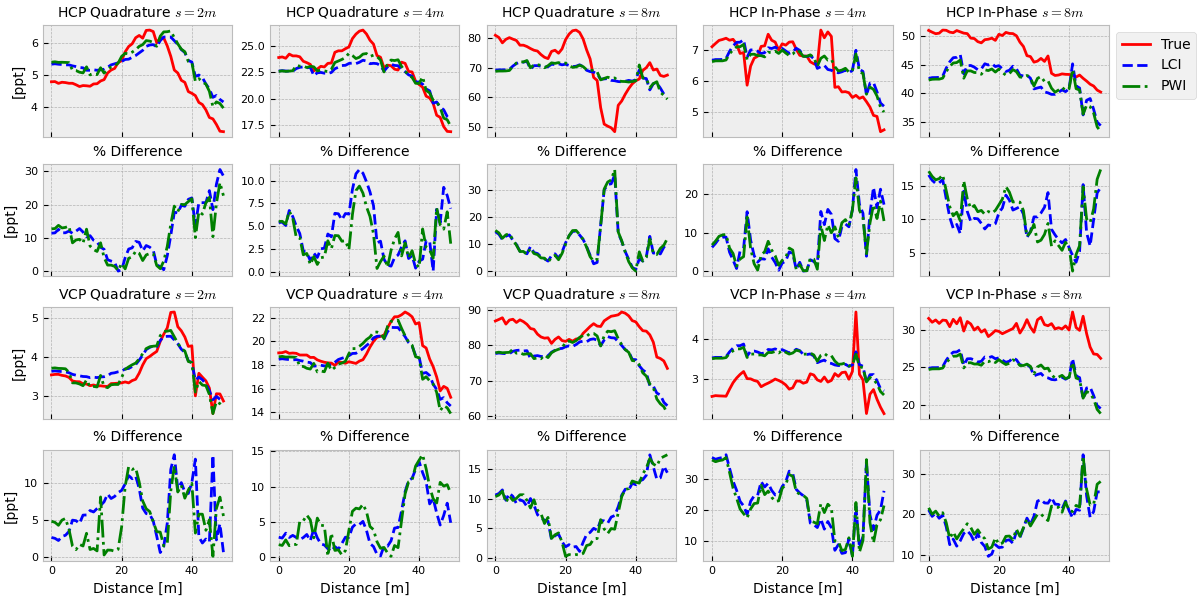

In [31]:
fig, ax = plt.subplots(4,5, sharex=True, figsize = (12,6), layout='constrained')

l = 36
fs = 10
fs2 = 8

# HCP
ax[0,0].plot(data_true[l,:,0]*1000, 'r')
ax[0,0].plot(data_inv[l,:,0]*1000, '--b')
ax[0,0].plot(data_inv_pw[l,:,0]*1000, '-.g')
ax[0,0].set_title('HCP Quadrature $s = 2m$', fontsize=fs)
ax[0,0].tick_params(labelsize=fs2)

ax[0,1].plot(data_true[l,:,1]*1000, 'r')
ax[0,1].plot(data_inv[l,:,1]*1000, '--b')
ax[0,1].plot(data_inv_pw[l,:,1]*1000, '-.g')
ax[0,1].set_title('HCP Quadrature $s = 4m$', fontsize=fs)
ax[0,1].tick_params(labelsize=fs2)

ax[0,2].plot(data_true[l,:,2]*1000, 'r')
ax[0,2].plot(data_inv[l,:,2]*1000, '--b')
ax[0,2].plot(data_inv_pw[l,:,2]*1000, '-.g')
ax[0,2].set_title('HCP Quadrature $s = 8m$', fontsize=fs)
ax[0,2].tick_params(labelsize=fs2)

ax[0,3].plot(data_true[l,:,6]*1000, 'r')
ax[0,3].plot(data_inv[l,:,6]*1000, '--b')
ax[0,3].plot(data_inv_pw[l,:,6]*1000, '-.g')
ax[0,3].set_title('HCP In-Phase $s = 4m$', fontsize=fs)
ax[0,3].tick_params(labelsize=fs2)

ax[0,4].plot(data_true[l,:,7]*1000, 'r', label='True')
ax[0,4].plot(data_inv[l,:,7]*1000, '--b', label='LCI')
ax[0,4].plot(data_inv_pw[l,:,7]*1000, '-.g', label='PWI')
ax[0,4].set_title('HCP In-Phase $s = 8m$', fontsize=fs)
ax[0,4].tick_params(labelsize=fs2)
ax[0,4].legend(bbox_to_anchor=(1,1))

# difference

ax[1,0].plot(np.abs((data_true[l,:,0] - data_inv[l,:,0])/data_true[l,:,0])*100, '--b')
ax[1,0].plot(np.abs((data_true[l,:,0] - data_inv_pw[l,:,0])/data_true[l,:,0])*100, '-.g')
ax[1,0].tick_params(labelsize=fs2)
ax[1,0].set_title('% Difference', fontsize=fs)

ax[1,1].plot(np.abs((data_true[l,:,1] - data_inv[l,:,1])/data_true[l,:,1])*100, '--b')
ax[1,1].plot(np.abs((data_true[l,:,1] - data_inv_pw[l,:,1])/data_true[l,:,1])*100, '-.g')
ax[1,1].tick_params(labelsize=fs2)
ax[1,1].set_title('% Difference', fontsize=fs)

ax[1,2].plot(np.abs((data_true[l,:,2] - data_inv[l,:,2])/data_true[l,:,2])*100, '--b')
ax[1,2].plot(np.abs((data_true[l,:,2] - data_inv_pw[l,:,2])/data_true[l,:,2])*100, '-.g')
ax[1,2].tick_params(labelsize=fs2)
ax[1,2].set_title('% Difference', fontsize=fs)

ax[1,3].plot(np.abs((data_true[l,:,6] - data_inv[l,:,6])/data_true[l,:,6])*100, '--b')
ax[1,3].plot(np.abs((data_true[l,:,6] - data_inv_pw[l,:,6])/data_true[l,:,6])*100, '-.g')
ax[1,3].tick_params(labelsize=fs2)
ax[1,3].set_title('% Difference', fontsize=fs)

ax[1,4].plot(np.abs((data_true[l,:,7] - data_inv[l,:,7])/data_true[l,:,7])*100, '--b')
ax[1,4].plot(np.abs((data_true[l,:,7] - data_inv_pw[l,:,7])/data_true[l,:,7])*100, '-.g')
ax[1,4].tick_params(labelsize=fs2)
ax[1,4].set_title('% Difference', fontsize=fs)

# VCP
ax[2,0].plot(data_true[l,:,3]*1000, 'r')
ax[2,0].plot(data_inv[l,:,3]*1000, '--b')
ax[2,0].plot(data_inv_pw[l,:,3]*1000, '-.g')
ax[2,0].set_title('VCP Quadrature $s = 2m$', fontsize=fs)
ax[2,0].tick_params(labelsize=fs2)

ax[2,1].plot(data_true[l,:,4]*1000, 'r')
ax[2,1].plot(data_inv[l,:,4]*1000, '--b')
ax[2,1].plot(data_inv_pw[l,:,4]*1000, '-.g')
ax[2,1].set_title('VCP Quadrature $s = 4m$', fontsize=fs)
ax[2,1].tick_params(labelsize=fs2)

ax[2,2].plot(data_true[l,:,5]*1000, 'r')
ax[2,2].plot(data_inv[l,:,5]*1000, '--b')
ax[2,2].plot(data_inv_pw[l,:,5]*1000, '-.g')
ax[2,2].set_title('VCP Quadrature $s = 8m$', fontsize=fs)
ax[2,2].tick_params(labelsize=fs2)

ax[2,3].plot(data_true[l,:,8]*1000, 'r')
ax[2,3].plot(data_inv[l,:,8]*1000, '--b')
ax[2,3].plot(data_inv_pw[l,:,8]*1000, '-.g')
ax[2,3].set_title('VCP In-Phase $s = 4m$', fontsize=fs)
ax[2,3].tick_params(labelsize=fs2)

ax[2,4].plot(data_true[l,:,9]*1000, 'r')
ax[2,4].plot(data_inv[l,:,9]*1000, '--b')
ax[2,4].plot(data_inv_pw[l,:,9]*1000, '-.g')
ax[2,4].set_title('VCP In-Phase $s = 8m$', fontsize=fs)
ax[2,4].tick_params(labelsize=fs2)

# difference

ax[3,0].plot(np.abs((data_true[l,:,3] - data_inv[l,:,3])/data_true[l,:,3])*100, '--b')
ax[3,0].plot(np.abs((data_true[l,:,3] - data_inv_pw[l,:,3])/data_true[l,:,3])*100, '-.g')
ax[3,0].tick_params(labelsize=fs2)
ax[3,0].set_title('% Difference', fontsize=fs)

ax[3,1].plot(np.abs((data_true[l,:,4] - data_inv[l,:,4])/data_true[l,:,4])*100, '--b')
ax[3,1].plot(np.abs((data_true[l,:,4] - data_inv_pw[l,:,4])/data_true[l,:,4])*100, '-.g')
ax[3,1].tick_params(labelsize=fs2)
ax[3,1].set_title('% Difference', fontsize=fs)

ax[3,2].plot(np.abs((data_true[l,:,5] - data_inv[l,:,5])/data_true[l,:,5])*100, '--b')
ax[3,2].plot(np.abs((data_true[l,:,5] - data_inv_pw[l,:,5])/data_true[l,:,5])*100, '-.g')
ax[3,2].tick_params(labelsize=fs2)
ax[3,2].set_title('% Difference', fontsize=fs)

ax[3,3].plot(np.abs((data_true[l,:,8] - data_inv[l,:,8])/data_true[l,:,8])*100, '--b')
ax[3,3].plot(np.abs((data_true[l,:,8] - data_inv_pw[l,:,8])/data_true[l,:,8])*100, '-.g')
ax[3,3].tick_params(labelsize=fs2)
ax[3,3].set_title('% Difference', fontsize=fs)

ax[3,4].plot(np.abs((data_true[l,:,9] - data_inv[l,:,9])/data_true[l,:,9])*100, '--b')
ax[3,4].plot(np.abs((data_true[l,:,9] - data_inv_pw[l,:,9])/data_true[l,:,9])*100, '-.g')
ax[3,4].tick_params(labelsize=fs2)
ax[3,4].set_title('% Difference', fontsize=fs)

ax[0,0].set_ylabel('[ppt]', fontsize=fs)
ax[1,0].set_ylabel('[ppt]', fontsize=fs)
ax[2,0].set_ylabel('[ppt]', fontsize=fs)
ax[3,0].set_ylabel('[ppt]', fontsize=fs)

ax[-1,0].set_xlabel('Distance [m]', fontsize=fs)
ax[-1,1].set_xlabel('Distance [m]', fontsize=fs)
ax[-1,2].set_xlabel('Distance [m]', fontsize=fs)
ax[-1,3].set_xlabel('Distance [m]', fontsize=fs)
ax[-1,4].set_xlabel('Distance [m]', fontsize=fs)

plt.savefig('figures/Field_Line'+str(l)+'.eps', format='eps')
plt.show()